
## Lab1.1: Análisis exploratorio de datos con PANDAS y NUMPY

In [14]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

df[:5]


,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las colujmnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png

## Laboratorio_1.1

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.




  



In [15]:
# 1:

# Filtramos por Isla:
torger = df[df['isla'] == "Torgersen"]

#Sacamos max y min
pico_min = torger['profundidad_pico (mm)'].min()
pico_max = torger['profundidad_pico (mm)'].max()

print(f'La profundidad del pico en las isla Torgersen mínima es: {pico_min} y la Máxima es: {pico_max}'  )


La profundidad del pico en las isla Torgersen mínima es: 15.9 y la Máxima es: 21.5


In [16]:
# 2:

# Con armax encontramos el indice con el mayor peso:

index = df['masa_corporal (g)'].argmax()

df1= df.iloc[[index]][['masa_corporal (g)', "isla", 'especie', 'genero']]
df1


,masa_corporal (g),isla,especie,genero
231,6300.0,Biscoe,Gentoo,Male


In [17]:
# 3:

# Filtros:
condiciones = (df['genero'] == "Male") & (df['especie'] != 'Gentoo')
# Sacamos la media:
prom = df[condiciones]['masa_corporal (g)'].mean()

print(f'La masa media de los pinguinos machos que no son de la Isla Gentoo es: {prom}')


La masa media de los pinguinos machos que no son de la Isla Gentoo es: 4010.2803738317757


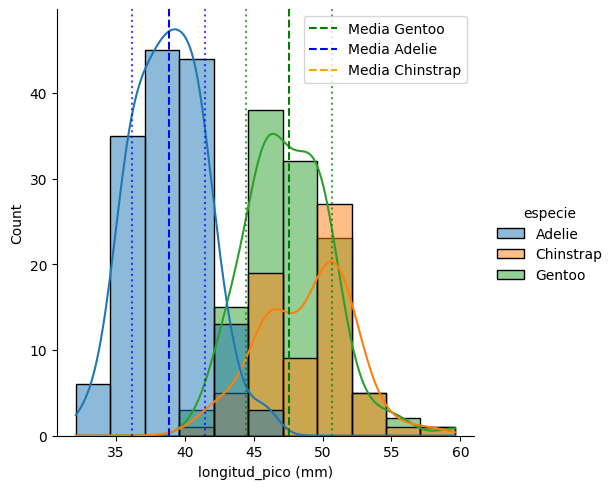

In [36]:
#4: 

# Calculando medias:
mediagentoo = df[(df['especie'] == 'Gentoo')]['longitud_pico (mm)'].mean()
mediaAdelie = df[(df['especie'] == 'Adelie')]['longitud_pico (mm)'].mean()
mediaChein = df[(df['especie'] == 'Cheinstrap')]['longitud_pico (mm)'].mean()

# Calculando desviaviones:
dsgentoo = df[(df['especie'] == 'Gentoo')]['longitud_pico (mm)'].std()
dsAdelie = df[(df['especie'] == 'Adelie')]['longitud_pico (mm)'].std()
dsChein = df[(df['especie'] == 'Cheinstrap')]['longitud_pico (mm)'].std()

#Por medio de Seaborn aplicamos histograma:
#fig, ax = plt.subplots(figsize=(12, 5))
sns.displot(data= df, x = 'longitud_pico (mm)', hue ='especie', kde = True ) 

 
plt.axvline(mediagentoo, color='green', linestyle='--', label='Media Gentoo')
plt.axvline(mediaAdelie, color='blue', linestyle='--', label='Media Adelie')
plt.axvline(mediaChein, color='orange', linestyle='--', label='Media Chinstrap')

# Añadir desviaciones estándar (líneas a izquierda y derecha de la media)
plt.axvline(mediagentoo - dsgentoo, color='green', linestyle=':', alpha=0.7)
plt.axvline(mediagentoo + dsgentoo, color='green', linestyle=':', alpha=0.7)

plt.axvline(mediaAdelie - dsAdelie, color='blue', linestyle=':', alpha=0.7)
plt.axvline(mediaAdelie + dsAdelie, color='blue', linestyle=':', alpha=0.7)

plt.axvline(mediaChein - dsChein, color='orange', linestyle=':', alpha=0.7)
plt.axvline(mediaChein + dsChein, color='orange', linestyle=':', alpha=0.7)

plt.legend()
plt.show()


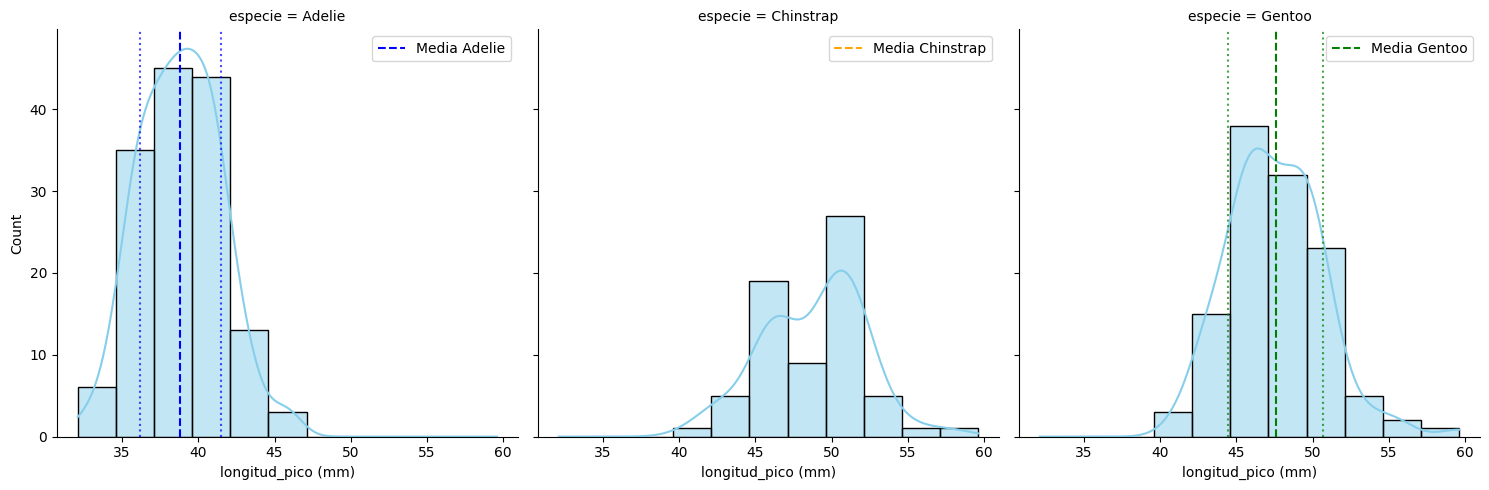

In [55]:
#Arreglando el punto 4 con IA:

g = sns.displot(data= df, x = 'longitud_pico (mm)', col='especie', kde = True, color = 'skyblue' ) 

# Diccionario con medias y desviaciones por especie
stats = {
    'Gentoo': (mediagentoo, dsgentoo, 'green'),
    'Adelie': (mediaAdelie, dsAdelie, 'blue'),
    'Chinstrap': (mediaChein, dsChein, 'orange')
}

# Iterar sobre cada subplot y añadir líneas
for ax in g.axes.flat:
    especie = ax.get_title().split(' = ')[-1]  # Extrae el nombre de la especie del título
    media, ds, color = stats[especie]

    # Línea de la media
    ax.axvline(media, color=color, linestyle='--', label=f'Media {especie}')
    # Líneas de desviación estándar
    ax.axvline(media - ds, color=color, linestyle=':', alpha=0.7)
    ax.axvline(media + ds, color=color, linestyle=':', alpha=0.7)

    ax.legend()
plt.tight_layout()




In [ ]:
# 5: Islas Presentes.
Islas = df['isla'].value_counts()
Islas

isla
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64

In [58]:
# 5: Especies Presentes.

df['especie'].value_counts()

especie
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

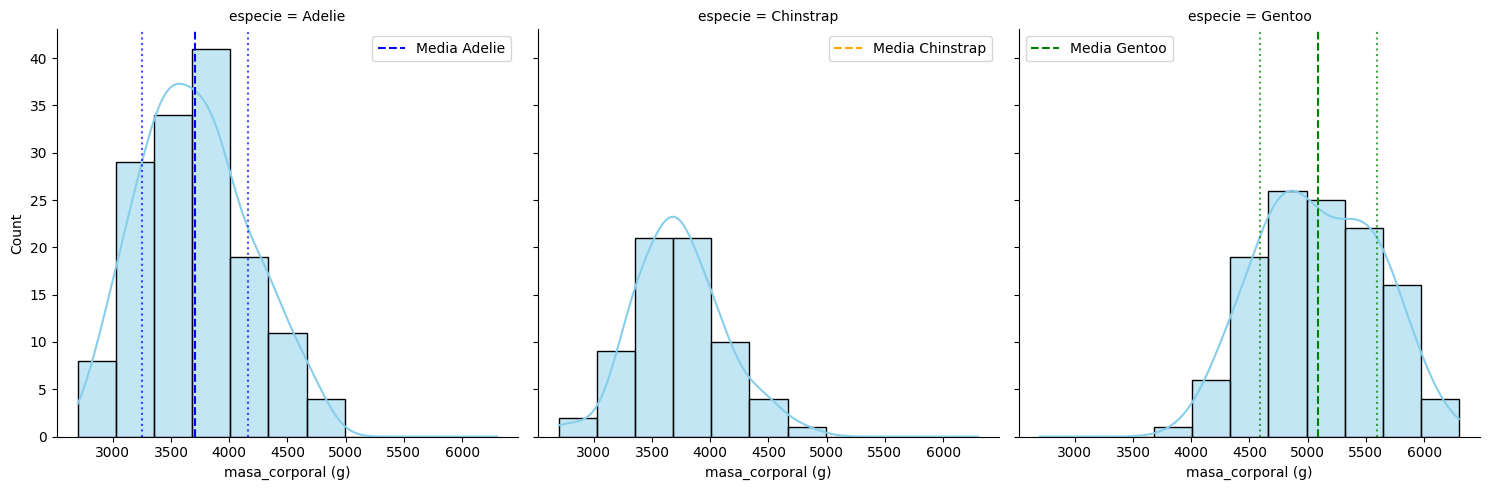

In [60]:
#5: Histograma para masas:

# Calculando medias:
mediagentoo = df[(df['especie'] == 'Gentoo')]['masa_corporal (g)'].mean()
mediaAdelie = df[(df['especie'] == 'Adelie')]['masa_corporal (g)'].mean()
mediaChein = df[(df['especie'] == 'Cheinstrap')]['masa_corporal (g)'].mean()

# Calculando desviaviones:
dsgentoo = df[(df['especie'] == 'Gentoo')]['masa_corporal (g)'].std()
dsAdelie = df[(df['especie'] == 'Adelie')]['masa_corporal (g)'].std()
dsChein = df[(df['especie'] == 'Cheinstrap')]['masa_corporal (g)'].std()



g = sns.displot(data= df, x = 'masa_corporal (g)', col='especie', kde = True, color = 'skyblue' ) 

# Diccionario con medias y desviaciones por especie
stats = {
    'Gentoo': (mediagentoo, dsgentoo, 'green'),
    'Adelie': (mediaAdelie, dsAdelie, 'blue'),
    'Chinstrap': (mediaChein, dsChein, 'orange')
}

# Iterar sobre cada subplot y añadir líneas
for ax in g.axes.flat:
    especie = ax.get_title().split(' = ')[-1]  # Extrae el nombre de la especie del título
    media, ds, color = stats[especie]

    # Línea de la media
    ax.axvline(media, color=color, linestyle='--', label=f'Media {especie}')
    # Líneas de desviación estándar
    ax.axvline(media - ds, color=color, linestyle=':', alpha=0.7)
    ax.axvline(media + ds, color=color, linestyle=':', alpha=0.7)

    ax.legend()
plt.tight_layout()